In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('C:/Users/User/Desktop/mnist_dataset.csv')
df

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
pip install pillow  

Note: you may need to restart the kernel to use updated packages.


In [2]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

D:\Aninst\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


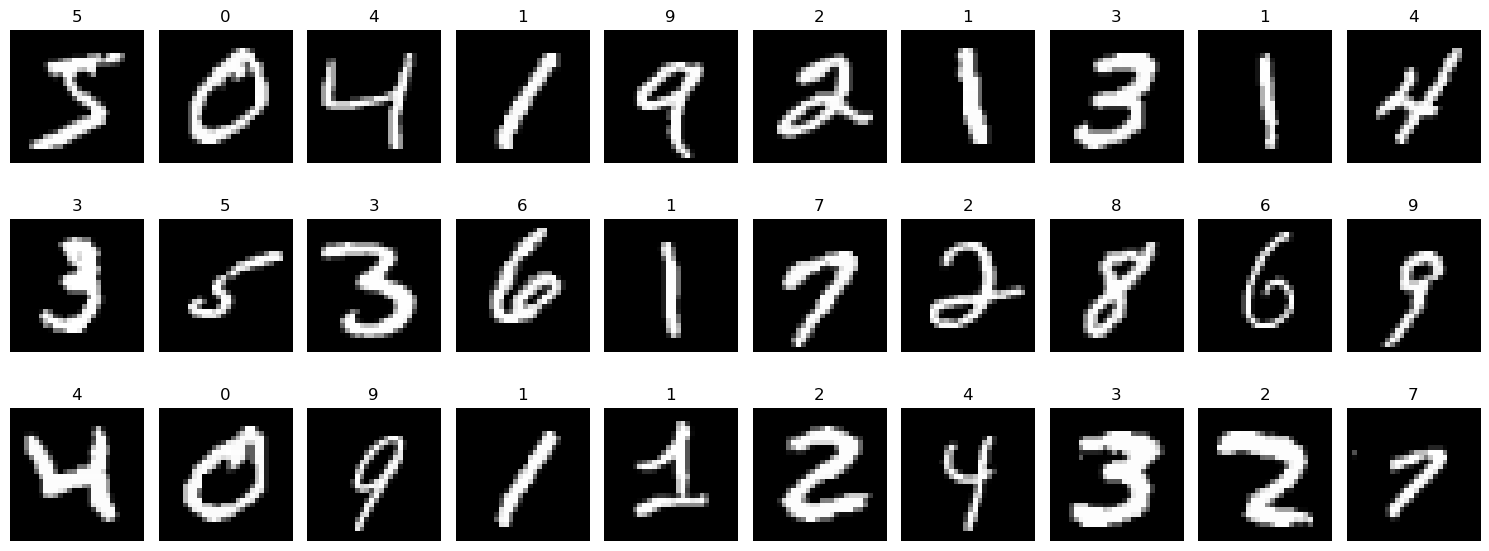

In [8]:
def mnist_images(images, labels, num_rows=3, num_cols=10):
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6))
    
    for i in range(num_rows):
        for j in range(num_cols):
            idx = i * num_cols + j
            axes[i, j].imshow(images[idx], cmap='gray')
            axes[i, j].set_title(f'{labels[idx]}')
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

mnist_images(x_train, y_train, num_rows=3, num_cols=10)

In [3]:
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from sklearn.pipeline import Pipeline

def preparation_mnist(x_train, x_test):
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    mean_image = np.mean(x_train, axis=0)
    x_train -= mean_image
    x_test -= mean_image

    return x_train, x_test, mean_image

class MnistClassifier:
    def __init__(self, epochs=10, batch_size=32, verbose=1):
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None  

    def fit(self, X, y):
        
        self.model = keras.Sequential([
            keras.layers.Flatten(input_shape=(28, 28)),
            keras.layers.Dense(256, activation='relu'),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(128, activation='relu'),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(10, activation='softmax')
        ])
        
        self.model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        self.model.fit(
            X, y,
            batch_size=self.batch_size,
            epochs=self.epochs,
            verbose=self.verbose
        )
        return self

    def predict(self, X):
        return np.argmax(self.model.predict(X, verbose=0), axis=1)
        
    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))
        
trainer = MnistClassifier(epochs=10, verbose=1)
trainer.fit(x_train, y_train)
print(f"accuracy: {trainer.score(x_test, y_test):.4f}")

pipe = Pipeline([
    ('mnistclas', trainer)  
])

print(pipe)
print(f"\n{list(pipe.named_steps.keys())}")


Epoch 1/10


D:\Aninst\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7704 - loss: 2.6469 
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8585 - loss: 0.5867
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8943 - loss: 0.4222
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9114 - loss: 0.3404
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9195 - loss: 0.3101
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9245 - loss: 0.2958
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9304 - loss: 0.2704
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9337 - loss: 0.2588
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9362 - loss: 0.2496
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9369 - loss: 0.2485
accuracy: 0.9560
Pipeline(steps=[('mnistclas',
                 <__main__.MnistClassifier object at 0x0000029D44EB6270>)])

['mni

In [4]:
trainer.model.save_weights('my_model.weights.h5')

In [14]:
itr = 15
predictions = trainer.predict(x_test[:itr])
probas = trainer.predict_proba(x_test[:itr])

print("num  predict probability")
for i in range(itr):
    print(f"{y_test[i]}     {predictions[i]}        {probas[i][predictions[i]]:.2%}")

num  predict probability
7     7        99.98%
2     2        99.89%
1     1        99.68%
0     0        99.89%
4     4        99.86%
1     1        99.72%
4     4        99.92%
9     9        94.12%
5     5        69.88%
9     9        97.54%
0     0        99.98%
6     6        97.76%
9     9        99.91%
0     0        99.99%
1     1        99.99%


In [5]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = trainer.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=range(10), columns=range(10))

print("Матрица ошибок (строки - истина, столбцы - предсказание):")
print(cm_df)

Матрица ошибок (строки - истина, столбцы - предсказание):
     0     1     2    3    4    5    6    7    8    9
0  969     0     1    0    0    0    1    1    8    0
1    0  1116     5    0    2    1    2    0    9    0
2    2     4  1001    1    5    0    1    3   14    1
3    0     0    16  943    0   19    0    7   17    8
4    0     0     3    0  958    0    4    2    4   11
5    8     0     0    6    0  853    4    1   15    5
6    9     4     0    0    6    4  928    0    7    0
7    0     7    14    0    9    0    0  985    2   11
8    4     1     2    5    6    3    1    3  944    5
9    2     4     0    5   19    7    0    6   13  953


In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin


def create_pairs(x_train_scaled, x_test_scaled, y_train, y_test):
    tensor_train = []
    tensor_test = []
    for i in range(len(x_train_scaled)):
        tensor_train.append([x_train_scaled[i], y_train[i]])
    for i in range(len(x_test_scaled)):
        tensor_test.append([x_test_scaled[i], y_test[i]])
    return tensor_train, tensor_test

def preparation_mnist(x_train, x_test):
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    mean_image = np.mean(x_train, axis=0)
    x_train -= mean_image
    x_test -= mean_image
    
    return x_train, x_test, mean_image
    
def reshape_mnist(x_train, x_test):
    img_size = x_train.shape[1] * x_train.shape[2] 
    x_train = x_train.reshape(-1, img_size)
    x_test = x_test.reshape(-1, img_size)
    
    return x_train, x_test, img_size  

x_train, x_test, mean_image = preparation_mnist(x_train, x_test)
x_train, x_test, img_size = reshape_mnist(x_train, x_test)

class MnistNeuralNet(nn.Module):
    def __init__(self, input_size=784, hidden_size1=256, hidden_size2=128, epochs=500, batch_size=32, lr=0.001, num_classes=10):
        super(MnistNeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.2)
        self.fc3 = nn.Linear(hidden_size2, 10)
    
    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.fc3(x)
        return x

class MnistClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, input_size=img_size, hidden_size1=256, hidden_size2=128, 
                 num_classes=10, epochs=10, batch_size=32, lr=0.001, verbose=1):
        self.input_size = input_size
        self.hidden_size1 = hidden_size1
        self.hidden_size2 = hidden_size2
        self.num_classes = num_classes
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.verbose = verbose
        self.model = None

    def fit(self, X, y):
        X_tensor = torch.FloatTensor(X)
        y_tensor = torch.LongTensor(y) 
        
        train_loader = DataLoader(
            TensorDataset(X_tensor, y_tensor), 
            batch_size=self.batch_size, 
            shuffle=True
        )
        
        self.model = MnistNeuralNet(
            input_size=self.input_size,
            hidden_size1=self.hidden_size1,
            hidden_size2=self.hidden_size2,
            num_classes=self.num_classes
        )
        
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()  

        for epoch in range(self.epochs):
            running_loss = 0.0
            correct = 0
            total = 0
            
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = self.model(batch_X) 
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
            
            if self.verbose:
                epoch_loss = running_loss / len(train_loader)
                epoch_acc = correct / total
                print(f'Эпоха {epoch+1}/{self.epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2%}')

        return self

    def predict(self, X):
        with torch.no_grad():
            outputs = self.model(torch.FloatTensor(X))
            return torch.argmax(outputs, dim=1).numpy()

    def predict_proba(self, X):
        with torch.no_grad():
            outputs = self.model(torch.FloatTensor(X))
            return torch.softmax(outputs, dim=1).numpy()
            
    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

    def save_weights(self, filepath): #сохранить веса
        torch.save(self.model.state_dict(), filepath)
    
    def load_weights(self, filepath): #загрузить
        self.model.load_state_dict(torch.load(filepath))
        return self
    
trainer2 = MnistClassifier(epochs=10, verbose=1)
trainer2.fit(x_train, y_train)
print(f"accuracy: {trainer2.score(x_test, y_test):.4f}")

pipeline = Pipeline([
    ('classifier', MnistClassifier(epochs=10, batch_size=32, lr=0.001))
])
print(pipeline)
print(f"\n{list(pipeline.named_steps.keys())}")

Эпоха 1/10, Loss: 0.2609, Accuracy: 92.14%
Эпоха 2/10, Loss: 0.1292, Accuracy: 96.07%
Эпоха 3/10, Loss: 0.1042, Accuracy: 96.73%
Эпоха 4/10, Loss: 0.0856, Accuracy: 97.37%
Эпоха 5/10, Loss: 0.0766, Accuracy: 97.57%
Эпоха 6/10, Loss: 0.0707, Accuracy: 97.82%
Эпоха 7/10, Loss: 0.0646, Accuracy: 97.94%
Эпоха 8/10, Loss: 0.0617, Accuracy: 98.04%
Эпоха 9/10, Loss: 0.0559, Accuracy: 98.23%
Эпоха 10/10, Loss: 0.0544, Accuracy: 98.26%
accuracy: 0.9710
Pipeline(steps=[('classifier', MnistClassifier())])

['classifier']


In [4]:
trainer2.save_weights('mnist_weights.pth')

In [7]:
itr = 25
predictions = trainer2.predict(x_test[:itr])
probas = trainer2.predict_proba(x_test[:itr])

print("num  predict probability")
for i in range(itr):
    print(f"{y_test[i]}     {predictions[i]}        {probas[i][predictions[i]]:.2%}")

num  predict probability
7     7        100.00%
2     2        100.00%
1     1        99.77%
0     0        100.00%
4     4        99.20%
1     1        100.00%
4     4        99.96%
9     9        99.83%
5     6        99.81%
9     9        100.00%
0     0        100.00%
6     6        99.99%
9     9        100.00%
0     0        100.00%
1     1        100.00%
5     5        99.83%
9     9        99.99%
7     7        100.00%
3     3        4.79%
4     4        100.00%
9     9        99.73%
6     6        99.99%
6     6        100.00%
5     5        100.00%
4     4        99.98%


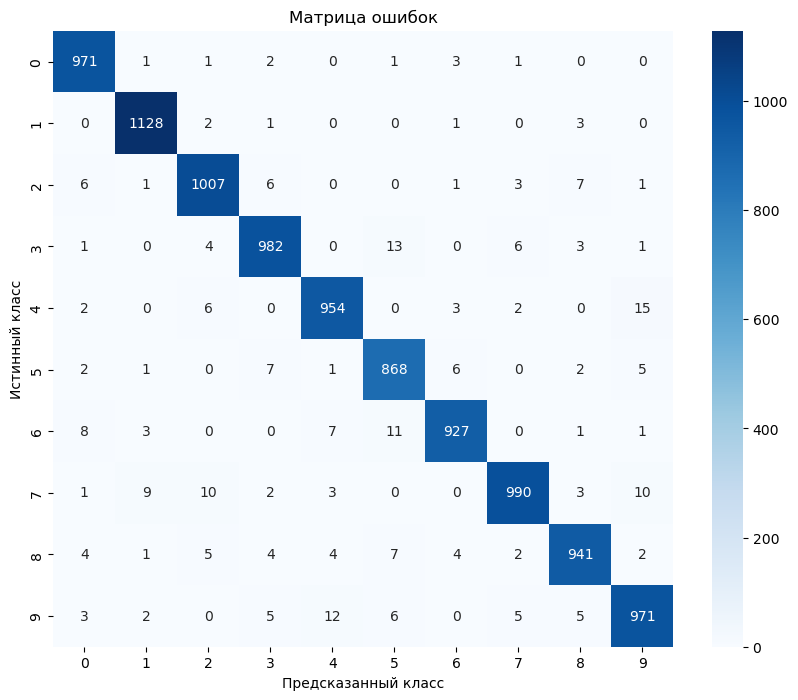

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = trainer2.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=range(10), columns=range(10))

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

In [22]:
df2 = pd.read_csv('C:/Users/User/Desktop/fashion-mnist_train.csv')
df3 = pd.read_csv('C:/Users/User/Desktop/fashion-mnist_test.csv')

In [12]:
df3

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [7]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

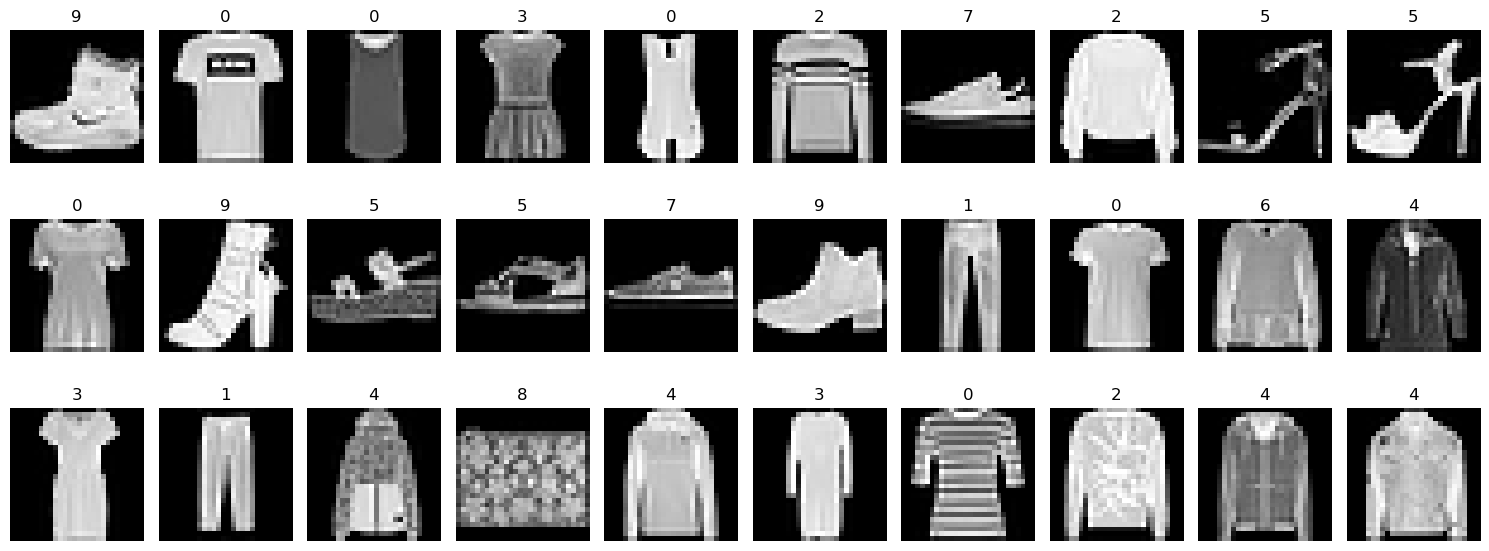

In [27]:
def mnist_images(images, labels, num_rows=3, num_cols=10):
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6))
    
    for i in range(num_rows):
        for j in range(num_cols):
            idx = i * num_cols + j
            axes[i, j].imshow(images[idx], cmap='gray')
            axes[i, j].set_title(f'{labels[idx]}')
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

mnist_images(x_train, y_train, num_rows=3, num_cols=10)

In [8]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

mean_image = np.mean(x_train, axis=0)
x_train -= mean_image
x_test -= mean_image

x_train = x_train.reshape(x_train.shape[0], -1)  
x_test = x_test.reshape(x_test.shape[0], -1)

train_df = pd.DataFrame(x_train)
train_df['label'] = y_train

test_df = pd.DataFrame(x_test)
test_df['label'] = y_test

df_all = pd.concat([train_df, test_df], axis=0, ignore_index=True)

df_features = df_all.drop('label', axis=1)

print({df_features.shape})

{(70000, 784)}


In [8]:
new_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(6, activation='softmax')
])

for i in range(len(saved_model.layers) - 1): 
    new_model.layers[i].set_weights(saved_model.layers[i].get_weights())
   
old_last_layer = saved_model.layers[-1]
old_weights, old_biases = old_last_layer.get_weights()

new_weights = old_weights[:, :new_num_classes]
new_biases = old_biases[:new_num_classes]

new_model.layers[-1].set_weights([new_weights, new_biases])

new_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

target_classes = list(range(new_num_classes))  

train_mask = np.isin(y_train_full, target_classes)
x_train = x_train_full[train_mask]
y_train = y_train_full[train_mask]

test_mask = np.isin(y_test_full, target_classes)
x_test = x_test_full[test_mask]
y_test = y_test_full[test_mask]

loss, acc = new_model.evaluate(x_test, y_test, verbose=0)

history = new_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

final_loss, final_acc = new_model.evaluate(x_test, y_test, verbose=0)
print(f"итоговая accuracy: {final_acc:.4f}")


Epoch 1/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7365 - loss: 0.6894 - val_accuracy: 0.8836 - val_loss: 0.3133
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8755 - loss: 0.3443 - val_accuracy: 0.8942 - val_loss: 0.2757
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8875 - loss: 0.3105 - val_accuracy: 0.9003 - val_loss: 0.2611
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8968 - loss: 0.2871 - val_accuracy: 0.9033 - val_loss: 0.2605
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9010 - loss: 0.2718 - val_accuracy: 0.9094 - val_loss: 0.2431
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9038 - loss: 0.2626 - val_accuracy: 0.9106 - val_loss: 0.2307
Epoch 7/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9088 - loss: 0.2544 - val_accuracy: 0.9150 - val_loss: 0.2322
Epoch 8/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9108 - loss: 0.2483 - val_accuracy: 0.

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


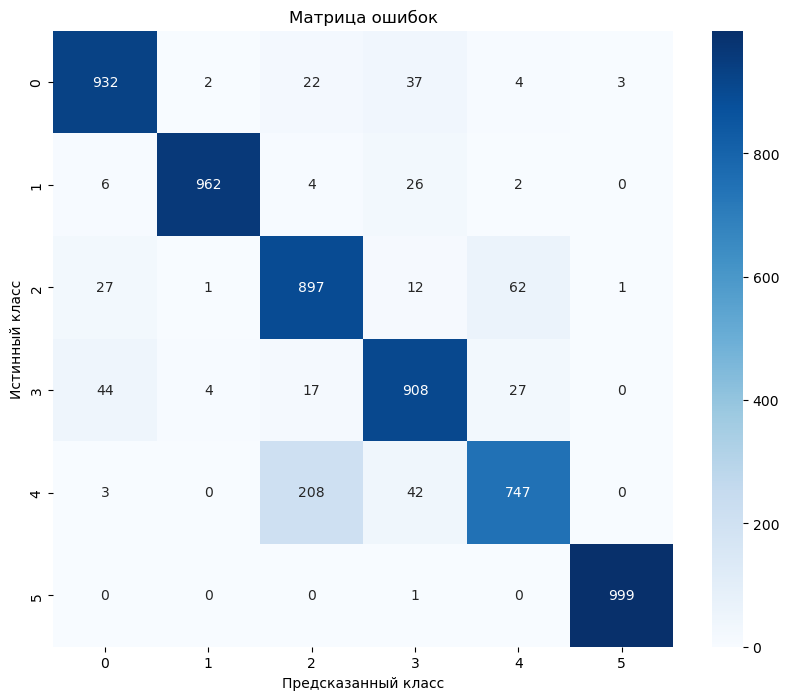

In [13]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

y_pred = new_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(6), yticklabels=range(6))
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


saved_model = MnistNeuralNet(num_classes=10)
saved_model.load_state_dict(torch.load('mnist_weights.pth'))
saved_model.eval()

new_model = MnistNeuralNet(num_classes=6)

new_model.fc1.weight.data = saved_model.fc1.weight.data.clone()
new_model.fc1.bias.data = saved_model.fc1.bias.data.clone()

new_model.fc2.weight.data = saved_model.fc2.weight.data.clone()
new_model.fc2.bias.data = saved_model.fc2.bias.data.clone()

old_fc3_weight = saved_model.fc3.weight.data 
old_fc3_bias = saved_model.fc3.bias.data      

new_fc3_weight = old_fc3_weight[:new_num_classes, :].clone()
new_fc3_bias = old_fc3_bias[:new_num_classes].clone()

new_model.fc3.weight.data = new_fc3_weight
new_model.fc3.bias.data = new_fc3_bias
new_model.eval()

train_mask = np.isin(y_train, target_classes)
x_train_filtered = x_train[train_mask]
y_train_filtered = y_train[train_mask]

test_mask = np.isin(y_test, target_classes)
x_test_filtered = x_test[test_mask]
y_test_filtered = y_test[test_mask]

X_train_tensor = torch.FloatTensor(x_train_filtered)
y_train_tensor = torch.LongTensor(y_train_filtered)
X_test_tensor = torch.FloatTensor(x_test_filtered)
y_test_tensor = torch.LongTensor(y_test_filtered)

with torch.no_grad():
    outputs = new_model(X_test_tensor)
    predictions = torch.argmax(outputs, dim=1)
    initial_acc = (predictions == y_test_tensor).float().mean().item()
    print(f"accuracy до обучения: {initial_acc:.4f}")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(new_model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    new_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = new_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    print(f'Эпоха {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')

with torch.no_grad():
    outputs = new_model(X_test_tensor)
    predictions = torch.argmax(outputs, dim=1)
    final_acc = (predictions == y_test_tensor).float().mean().item()
    print(f"итоговая accuracy: {final_acc:.4f}")

accuracy до обучения: 0.0828
Эпоха 1/10, Loss: 0.6888, Accuracy: 0.8017
Эпоха 2/10, Loss: 0.3240, Accuracy: 0.8820
Эпоха 3/10, Loss: 0.2777, Accuracy: 0.8998
Эпоха 4/10, Loss: 0.2540, Accuracy: 0.9084
Эпоха 5/10, Loss: 0.2327, Accuracy: 0.9152
Эпоха 6/10, Loss: 0.2222, Accuracy: 0.9189
Эпоха 7/10, Loss: 0.2088, Accuracy: 0.9231
Эпоха 8/10, Loss: 0.1986, Accuracy: 0.9261
Эпоха 9/10, Loss: 0.1859, Accuracy: 0.9316
Эпоха 10/10, Loss: 0.1810, Accuracy: 0.9332
итоговая accuracy: 0.9097


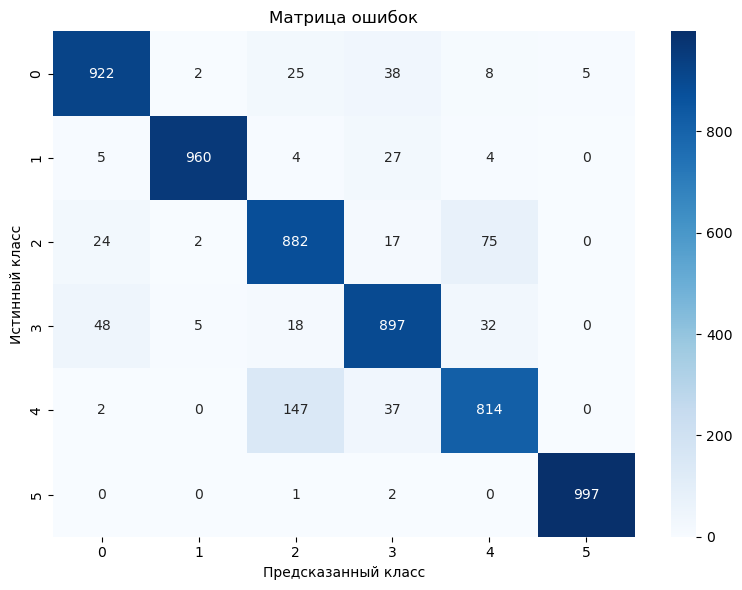

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_filtered, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(6), yticklabels=range(6))
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()
